### Inventory Management and Maximise Profitability 

#### ***Forecasting***

Time series forecasting method such as Prophet and ARIMA will be used to predict future series for each of the category of product

- **Prophet** forecasting model: It is designed to handle messy real-world time series data with missing values, outliers, and strong seasonal effects.
- **ARIMA** forecasting model (AutoRgeresive Integrated Moving Average): A well-known statistical model  for time series forecasting. It uses three components: **AR** Uses past values, **I** Differencing the series to make it stationary, **MA** uses past forecast errors.
- **Holt-Winters** (Exponential smoothening): 

#### *Evaluation Metrics*
- **MAE** : Mean Absolute Error, measures the average of the absolute differences between the actual and the predicted values.
- **RMSE** : Root Mean Square Error, penalises larger erros more because it squares the difference
- **MAPE** : Mean Absolute Percentage Error, absolute error expressed as percentage of the actual value.

 #### ***Import Dependencies***

In [101]:
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error,mean_absolute_percentage_error, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [102]:
df = pd.read_csv(r'C:\Users\ASUS PC\Desktop\AMDARI INTERNSHIP\Amdari\ElectroTech-Sales-Forecast\Model training\EDA_data.csv')

In [103]:
df.head()

,Product_ID,Category,Price,Date,Season,Market_Trend_Index,Competitor_Activity_Score,Consumer_Confidence_Index,Product_Specification_1,Product_Specification_2,Sales_Volume,Year,Month
0,1103,Laptop,105.32,2009-01-01,Winter,-1.859160,0.546694,84.680465,Spec_C,Long-Battery-Life,49,2009,January
1,1436,Tablet,145.55,2009-01-01,Winter,-0.345587,0.940428,42.919288,Spec_C,Lightweight,69,2009,January
2,1271,Smartphone,97.82,2009-01-01,Winter,-0.384738,0.751155,55.191268,Spec_B,Lightweight,50,2009,January
3,1107,Laptop,64.00,2009-01-01,Winter,0.716763,0.125939,88.746454,Spec_B,High-Resolution,28,2009,January
4,1072,Tablet,67.83,2009-01-01,Winter,-0.242074,-0.412932,67.947536,Spec_A,Long-Battery-Life,81,2009,January


In [104]:
sales_by_week_category = df.copy()

sales_by_week_category['Date'] = sales_by_week_category['Date'].astype('datetime64[ns]')

sales_by_week_category['Date'] = sales_by_week_category['Date'].dt.to_period('W')

sales_by_week_category = sales_by_week_category.groupby(['Date', 'Category']).sum()['Sales_Volume'].reset_index()


sales_by_week_category['Date'] = sales_by_week_category['Date'].dt.to_timestamp()

sales_by_week_category

,Date,Category,Sales_Volume
0,2008-12-29,Accessories,1405
1,2008-12-29,Laptop,1341
2,2008-12-29,Smartphone,1322
3,2008-12-29,Tablet,2070
4,2009-01-05,Accessories,3131
...,...,...,...
2503,2020-12-21,Tablet,7153
2504,2020-12-28,Accessories,2312
2505,2020-12-28,Laptop,2108
2506,2020-12-28,Smartphone,5723


#### **Univariate Forecasting**

In [105]:
sales_by_week_category = df.copy()

sales_by_week_category['Date'] = pd.to_datetime(sales_by_week_category['Date'])

sales_by_week_category['Date'] = sales_by_week_category['Date'].dt.to_period('W')
sales_by_week_category = sales_by_week_category.groupby(['Date','Category']).sum()['Sales_Volume'].reset_index()

sales_by_week_category['Date'] = sales_by_week_category['Date'].dt.to_timestamp()
sales_by_week_category

,Date,Category,Sales_Volume
0,2008-12-29,Accessories,1405
1,2008-12-29,Laptop,1341
2,2008-12-29,Smartphone,1322
3,2008-12-29,Tablet,2070
4,2009-01-05,Accessories,3131
...,...,...,...
2503,2020-12-21,Tablet,7153
2504,2020-12-28,Accessories,2312
2505,2020-12-28,Laptop,2108
2506,2020-12-28,Smartphone,5723


#### Forecasting and Evaluating Weekly Using Prophet model
- Daily forecasting introduces a lot of flunctuation that may be difficult to control
- with weekly forecast, we can easily aggregate sales for a short period of time and forecast easily

In [106]:
train_data_by_week = dict()
test_data_by_week = {}

for category in sales_by_week_category['Category'].unique():
    category_data_weekly =sales_by_week_category[sales_by_week_category['Category'] == category][['Date', 'Sales_Volume']]
    
    category_data_weekly = category_data_weekly.rename(columns={'Date': 'ds', 'Sales_Volume': 'y'})
    
    train_data_by_week[category] = category_data_weekly[category_data_weekly['ds'].dt.year < 2019]
    test_data_by_week[category] = category_data_weekly[category_data_weekly['ds'].dt.year >= 2019]
  

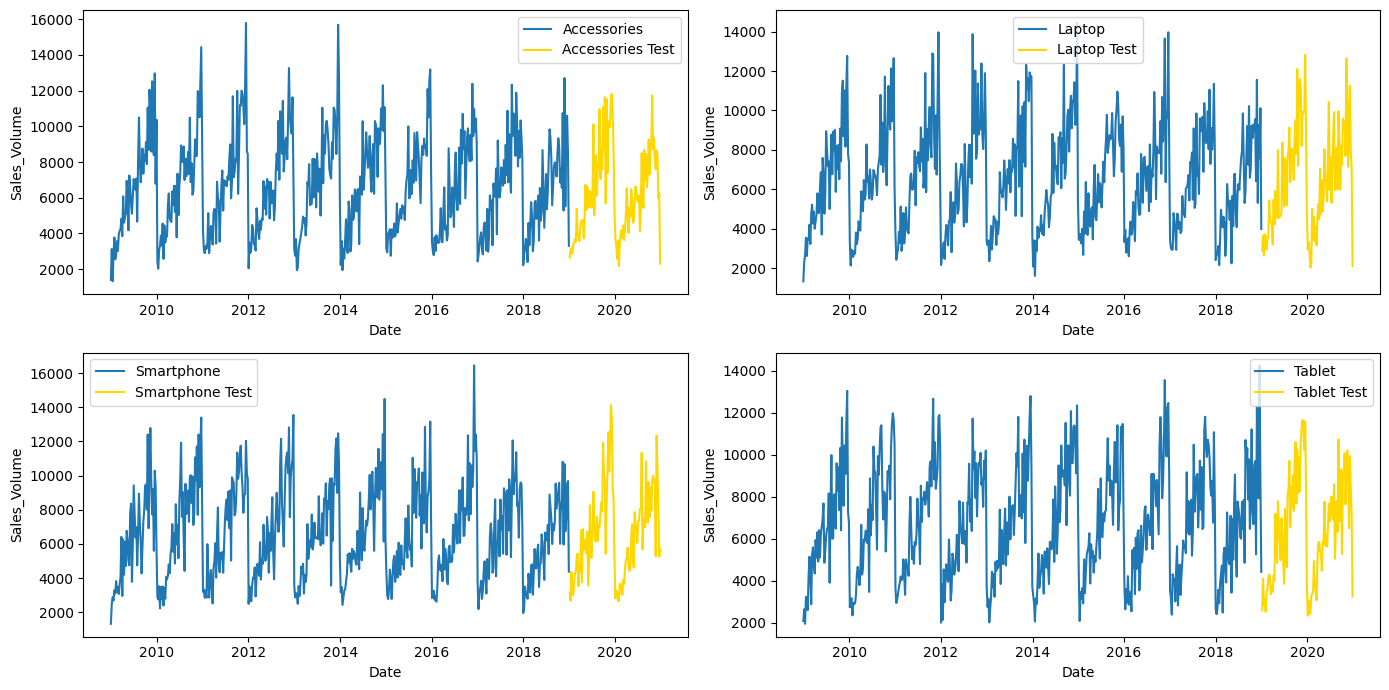

In [107]:
plt.figure(figsize=[14,7])

for i in range(4):
    category = sales_by_week_category['Category'].unique()[i]

    plt.subplot(2,2,i+1)
    plt.plot(train_data_by_week[category]['ds'], train_data_by_week[category]['y'], label=category)
    plt.plot(test_data_by_week[category]['ds'], test_data_by_week[category]['y'], label=f"{category} Test", color='gold')
    
    plt.xlabel('Date')
    plt.ylabel('Sales_Volume')
    plt.legend()
plt.tight_layout()
plt.show()



In [108]:
prophet_weekly_model = {}
#for category in sales_by_week_category['Category'].unique():
for i in range(4):
    category = sales_by_week_category['Category'].unique()[i]
    model = Prophet()
    model.fit(train_data_by_week[category])
    prophet_weekly_model[category] = model

03:55:52 - cmdstanpy - INFO - Chain [1] start processing
03:55:52 - cmdstanpy - INFO - Chain [1] done processing
03:55:52 - cmdstanpy - INFO - Chain [1] start processing
03:55:52 - cmdstanpy - INFO - Chain [1] done processing
03:55:53 - cmdstanpy - INFO - Chain [1] start processing
03:55:53 - cmdstanpy - INFO - Chain [1] done processing
03:55:53 - cmdstanpy - INFO - Chain [1] start processing
03:55:53 - cmdstanpy - INFO - Chain [1] done processing


In [109]:
prophet_weekly_model

{'Accessories': <prophet.forecaster.Prophet at 0x1eff5f0fdd0>,
 'Laptop': <prophet.forecaster.Prophet at 0x1eff5ef86b0>,
 'Smartphone': <prophet.forecaster.Prophet at 0x1eff77615b0>,
 'Tablet': <prophet.forecaster.Prophet at 0x1eff76f71a0>}

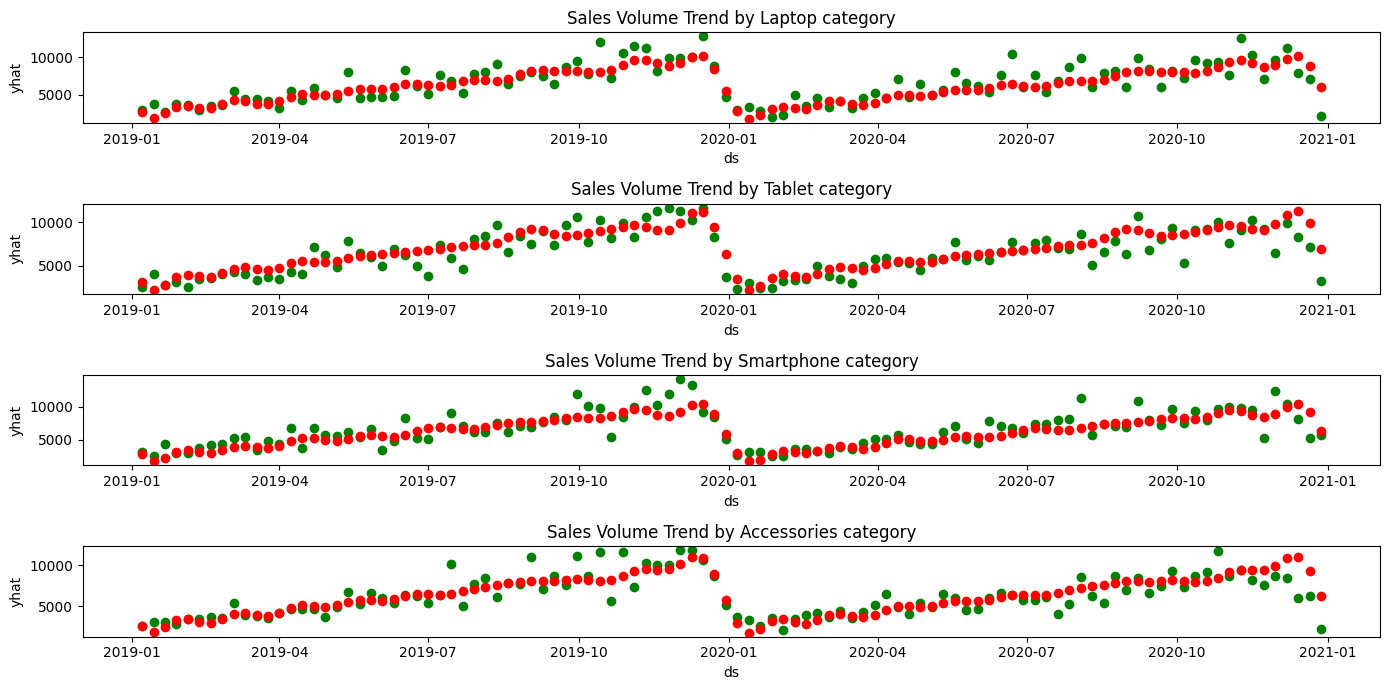

In [110]:

prophet_week_forecast = {}

fig, ax = plt.subplots(4,1,figsize=(14,7))

for i in range(4):
    category = df['Category'].unique()[i]
    prophet_week_forecast[category] = prophet_weekly_model[category].predict(test_data_by_week[category])

    ax[i].scatter(test_data_by_week[category]['ds'], test_data_by_week[category]['y'], color = 'green')
    ax[i].scatter(prophet_week_forecast[category]['ds'],prophet_week_forecast[category]['yhat'], label = 'predicted', color = 'red')
    ax[i].set_title(f'Sales Volume Trend by {category} category')
    ax[i].set_xlabel('ds')
    ax[i].set_ylabel('yhat')
   
plt.tight_layout()
plt.show()


In [111]:
mae, mape, rmse = 0, 0, 0
for category in sales_by_week_category['Category'].unique():
    mae += mean_absolute_error(test_data_by_week[category]['y'], prophet_week_forecast[category]['yhat'])
    mape += mean_absolute_percentage_error(test_data_by_week[category]['y'],prophet_week_forecast[category]['yhat'])
    rmse += root_mean_squared_error(test_data_by_week[category]['y'],prophet_week_forecast[category]['yhat'])

mae /= 4
mape /= 4
rmse /= 4
print(f"MAE: {round(mae,2)}")
print(f"MAPE: {round(mape * 100,2)} %")
print(f"RMSE: {round(rmse,2)}")



MAE: 1087.98
MAPE: 18.28 %
RMSE: 1427.93


In [112]:
sales_by_month_category = df.copy()

sales_by_month_category['Date'] = sales_by_month_category['Date'].astype('datetime64[ns]')

sales_by_month_category['Date'] = sales_by_month_category['Date'].dt.to_period('M')

sales_by_month_category = sales_by_month_category.groupby(['Date', 'Category']).sum()['Sales_Volume'].reset_index()


sales_by_month_category['Date'] = sales_by_month_category['Date'].dt.to_timestamp()

sales_by_month_category

,Date,Category,Sales_Volume
0,2009-01-01,Accessories,11762
1,2009-01-01,Laptop,11989
2,2009-01-01,Smartphone,12192
3,2009-01-01,Tablet,12491
4,2009-02-01,Accessories,12086
...,...,...,...
571,2020-11-01,Tablet,38059
572,2020-12-01,Accessories,30717
573,2020-12-01,Laptop,37869
574,2020-12-01,Smartphone,40987


In [113]:
train_data_by_month = {}
test_data_by_month = {}

for category in sales_by_month_category['Category'].unique():
    category_data_monthly =sales_by_month_category[sales_by_month_category['Category'] == category][['Date', 'Sales_Volume']]
    
    category_data_monthly = category_data_monthly.rename(columns={'Date': 'ds', 'Sales_Volume': 'y'})
    
    train_data_by_month[category] = category_data_monthly[category_data_monthly['ds'].dt.year < 2019]
    test_data_by_month[category] = category_data_monthly[category_data_monthly['ds'].dt.year >= 2019]

In [114]:
prophet_monthly_model = {}
for category in sales_by_month_category['Category'].unique():
    model = Prophet()
    model.fit(train_data_by_month[category])
    prophet_monthly_model[category] = model

03:55:54 - cmdstanpy - INFO - Chain [1] start processing
03:55:55 - cmdstanpy - INFO - Chain [1] done processing
03:55:55 - cmdstanpy - INFO - Chain [1] start processing
03:55:55 - cmdstanpy - INFO - Chain [1] done processing
03:55:55 - cmdstanpy - INFO - Chain [1] start processing
03:55:55 - cmdstanpy - INFO - Chain [1] done processing
03:55:55 - cmdstanpy - INFO - Chain [1] start processing
03:55:55 - cmdstanpy - INFO - Chain [1] done processing


In [115]:
prophet_monthly_model

{'Accessories': <prophet.forecaster.Prophet at 0x1eff68d64e0>,
 'Laptop': <prophet.forecaster.Prophet at 0x1eff675f1d0>,
 'Smartphone': <prophet.forecaster.Prophet at 0x1eff68bc890>,
 'Tablet': <prophet.forecaster.Prophet at 0x1eff676a630>}

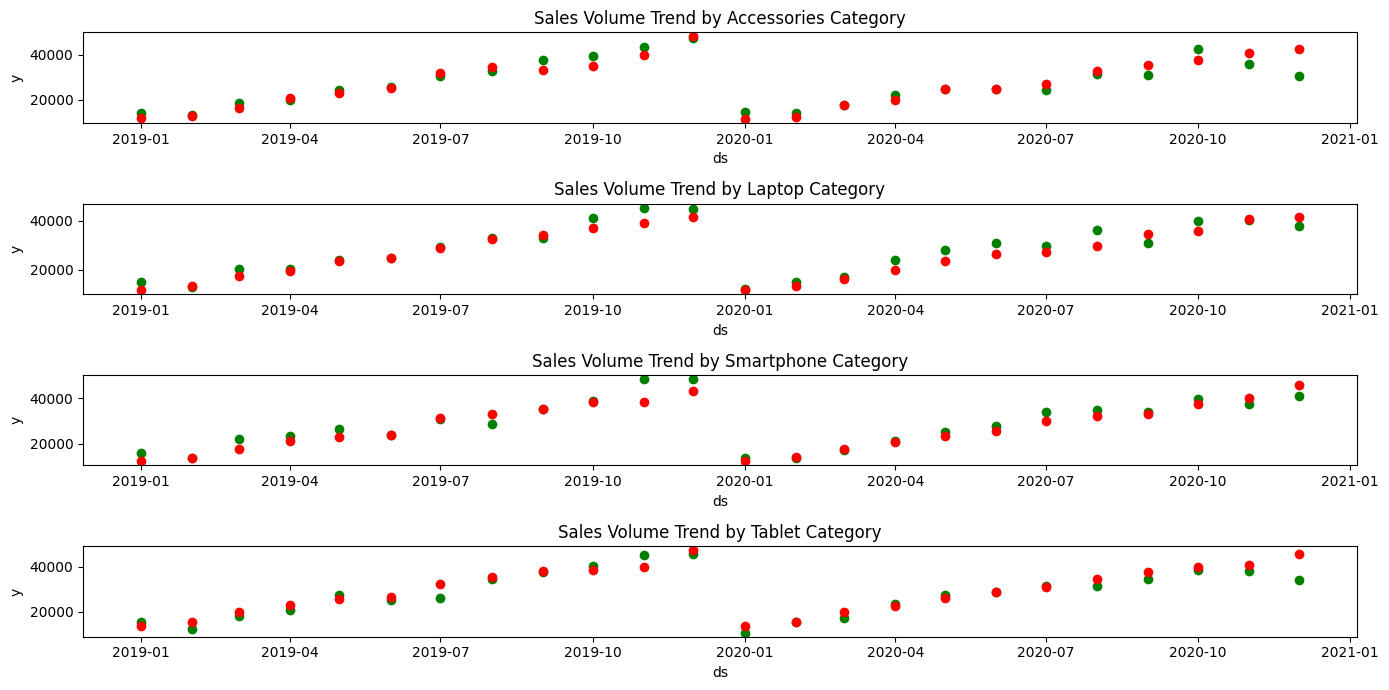

In [116]:

prophet_month_forecast = dict()

fig, ax = plt.subplots(4, 1, figsize=(14, 7))

for i in range(4):
    category = sales_by_month_category['Category'].unique()[i]
    
    prophet_month_forecast[category] = prophet_monthly_model[category].predict(test_data_by_month[category])
    
    ax[i].scatter(test_data_by_month[category]['ds'], test_data_by_month[category]['y'], label='Actual', color = 'green')
    ax[i].scatter(prophet_month_forecast[category]['ds'], prophet_month_forecast[category]['yhat'], label='Predicted', color = 'red') 
    ax[i].set_title(f"Sales Volume Trend by {category} Category")
    ax[i].set_xlabel('ds')
    ax[i].set_ylabel('y')
plt.tight_layout()
plt.show()

In [117]:
mae, mape, rmse = 0, 0, 0
for category in sales_by_month_category['Category'].unique():
    mae += mean_absolute_error(test_data_by_month[category]['y'],prophet_month_forecast[category]['yhat'])
    mape += mean_absolute_percentage_error(test_data_by_month[category]['y'],prophet_month_forecast[category]['yhat'])
    rmse += root_mean_squared_error(test_data_by_month[category]['y'],prophet_month_forecast[category]['yhat'])

mae /= 4
mape /= 4
rmse /= 4
print(f"MAE: {round(mae,2)}")
print(f"MAPE: {round(mape * 100,2)} %")
print(f"RMSE: {round(rmse,2)}")

MAE: 2487.01
MAPE: 9.0 %
RMSE: 3354.73


### **Forecasting  and Evaluating weekly Sales_Volume using ARIMA MODEL**
ARIMA stands for AutoRegressive Integrated Moving Average
Before one can build a model on ARIMA, it's necessary to check the stationarity of the dataset, as this is a requirement for using ARIMA. Stationarity simply means that the statistical properties like the mean and variance of the dataset does not change overtime.

To do the stationarity tes, The Augmented Dickery-Fuller test will be used. We begin by defining the function that we will use.

In [118]:

sales_by_week_category = df.copy()
sales_by_week_category['Date'] = pd.to_datetime(sales_by_week_category['Date'])
sales_by_week_category['Date'] = sales_by_week_category['Date'].dt.to_period('W')
#sales_by_week_category.index = pd.DatetimeIndex(df.index, freq='W-MON')
sales_by_week_category = sales_by_week_category.groupby(['Date', 'Category']).sum()['Sales_Volume'].reset_index()
sales_by_week_category['Date'] = sales_by_week_category['Date'].dt.to_timestamp()


In [119]:
train_data_by_week = {}
test_data_by_week = {}

for category in sales_by_week_category['Category'].unique():
    category_data_weekly = sales_by_week_category[sales_by_week_category['Category'] == category][['Date', 'Sales_Volume']]
    category_data_weekly = category_data_weekly.rename(columns={'Date': 'ds', 'Sales_Volume': 'y'})
    
    train_data_by_week[category] = category_data_weekly[category_data_weekly['ds'].dt.year < 2019].set_index('ds')
    test_data_by_week[category] = category_data_weekly[category_data_weekly['ds'].dt.year >= 2019].set_index('ds')


In [120]:
arima_weekly_model = {}
arima_weekly_forecast = {}

for category in sales_by_week_category['Category'].unique():
    # Fit ARIMA
    model = ARIMA(train_data_by_week[category]['y'], order=(1, 1, 1))
    fitted_model = model.fit()
    arima_weekly_model[category] = fitted_model

    # Forecast same length as test set
    steps = len(test_data_by_week[category])
    forecast = fitted_model.forecast(steps=steps)
    forecast.index = test_data_by_week[category].index  # Align dates

    arima_weekly_forecast[category] = forecast


c:\Users\ASUS PC\Desktop\AMDARI INTERNSHIP\RederTelecomChurn\Amdari-Telecom-Churn\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\ASUS PC\Desktop\AMDARI INTERNSHIP\RederTelecomChurn\Amdari-Telecom-Churn\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\ASUS PC\Desktop\AMDARI INTERNSHIP\RederTelecomChurn\Amdari-Telecom-Churn\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\ASUS PC\Desktop\AMDARI INTERNSHIP\RederTelecomChurn\Amdari-Telecom-Churn\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was 

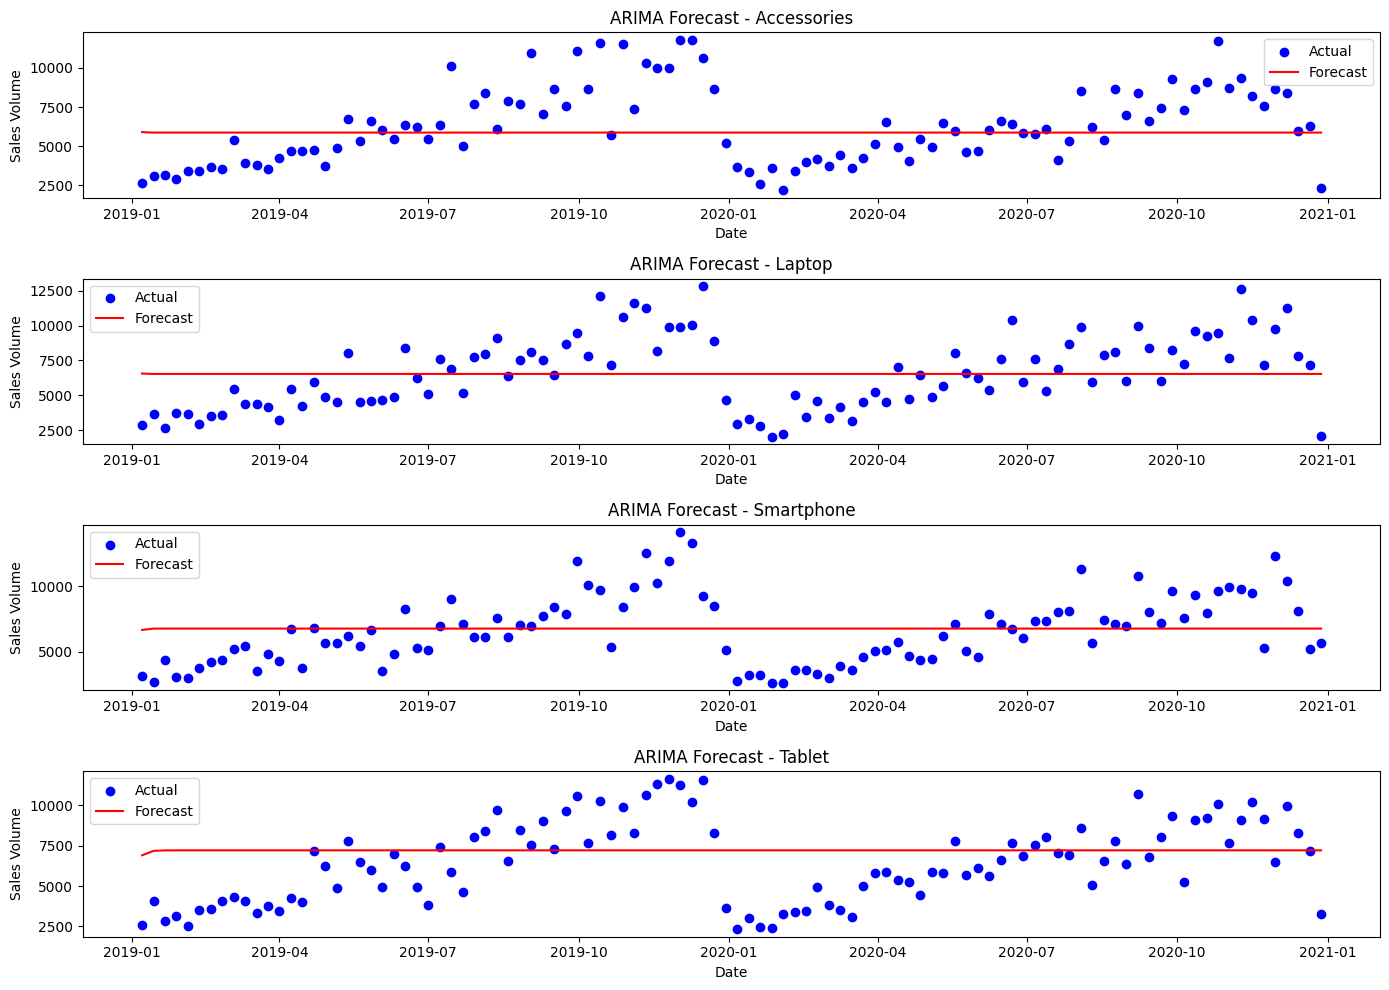

In [121]:
fig, ax = plt.subplots(4, 1, figsize=(14, 10))

for i, category in enumerate(sales_by_week_category['Category'].unique()[:4]):
    ax[i].scatter(test_data_by_week[category].index, test_data_by_week[category]['y'], label='Actual', color='blue')
    ax[i].plot(test_data_by_week[category].index, arima_weekly_forecast[category], label='Forecast', color='red')
    ax[i].set_title(f'ARIMA Forecast - {category}')
    ax[i].set_xlabel('Date')
    ax[i].set_ylabel('Sales Volume')
    ax[i].legend()

plt.tight_layout()
plt.show()


In [122]:
mae, mape, rmse = 0, 0, 0
for category in sales_by_week_category['Category'].unique():
    y_true = test_data_by_week[category]['y']
    y_pred = arima_weekly_forecast[category]
    
    mae += mean_absolute_error(y_true, y_pred)
    mape += mean_absolute_percentage_error(y_true, y_pred)
    rmse += np.sqrt(mean_squared_error(y_true, y_pred))

mae /= 4
mape /= 4
rmse /= 4

print(f"ARIMA MAE: {round(mae,2)}")
print(f"ARIMA MAPE: {round(mape * 100,2)} %")
print(f"ARIMA RMSE: {round(rmse,2)}")


ARIMA MAE: 2125.38
ARIMA MAPE: 41.28 %
ARIMA RMSE: 2572.16


In [123]:
import pickle

In [124]:
for category in sales_by_month_category['Category'].unique():
    with open(f'{category}_model.pkl', 'wb') as file:
        pickle.dump((prophet_monthly_model[category], train_data_by_month[category].columns),file)